In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import gseapy as gp
import os
import pickle

import subcluster_funcs as funcs
sc._settings.settings._vector_friendly=True

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
post_subclustering_dir = "../post_subcluster_annotation/"
os.makedirs(post_subclustering_dir, exist_ok=True)
plots_dir = "plots_dir/"
os.makedirs(plots_dir, exist_ok=True)

In [3]:
cell_type = "vSMC"

In [4]:
%%time
adata = sc.read_h5ad("../continuous_cov_corrected_no_scvi/" + cell_type  + ".h5ad")

CPU times: user 32 s, sys: 5.21 s, total: 37.2 s
Wall time: 1min 2s


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>

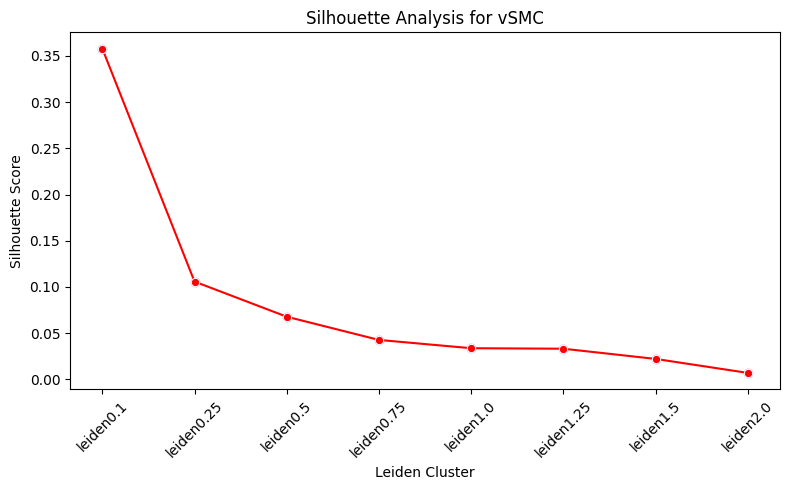

In [5]:
funcs.silhouette(adata, silhouette_res_dir = "../silhouette_res_scVI/", cell_type = cell_type)

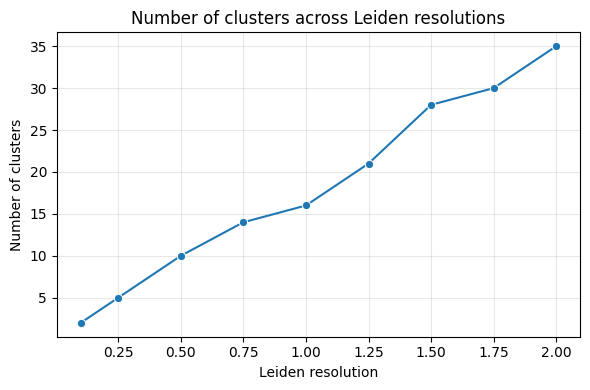

In [6]:
cluster_df, fig = funcs.leiden_resolution_summary(adata)

### Use Leiden 0.25 

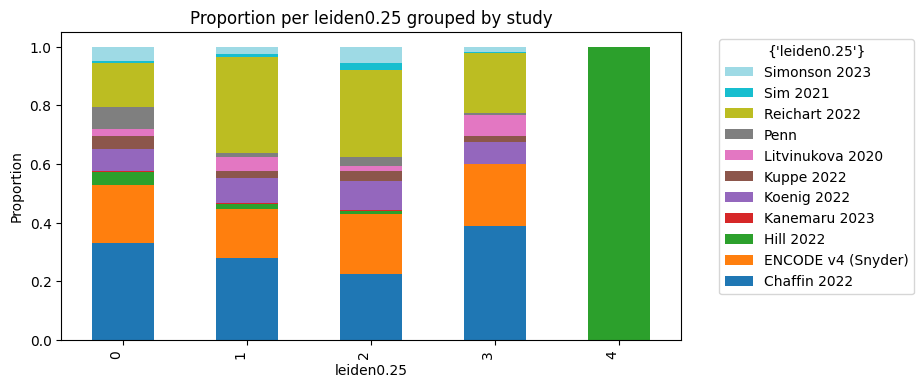

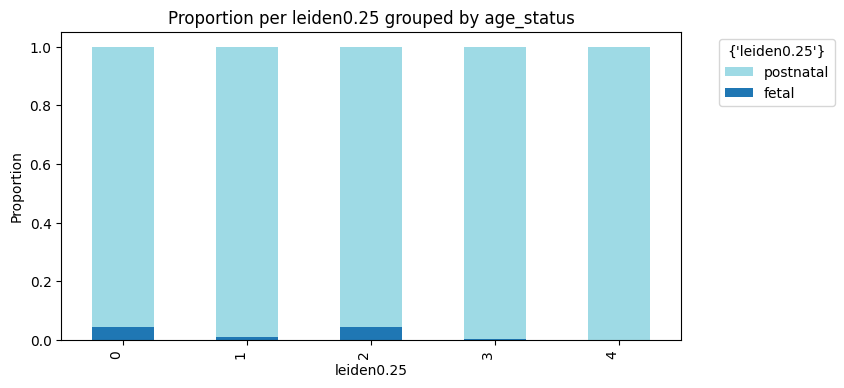

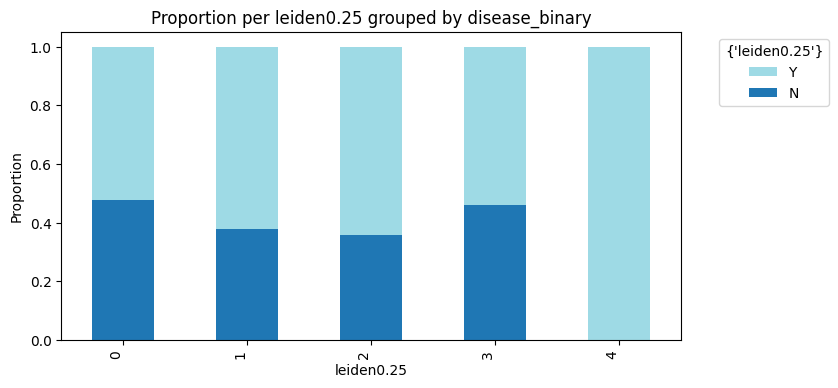

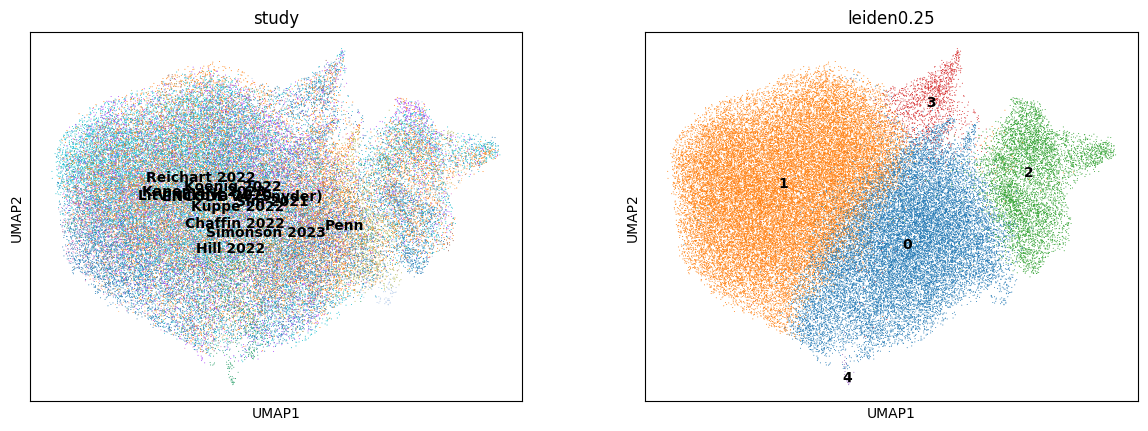

/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 16115 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


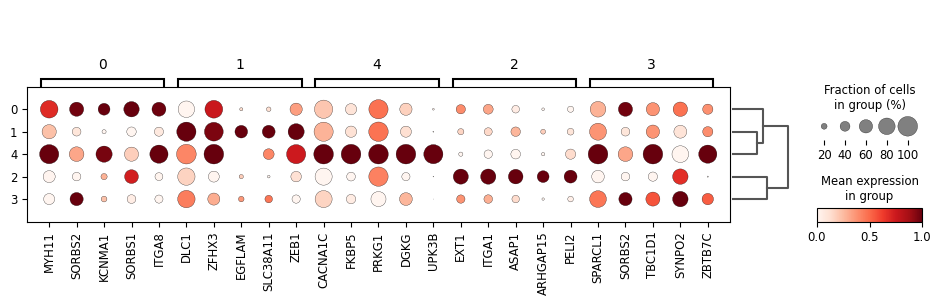

Counter({'1': 31651, '0': 20456, '2': 5741, '3': 1478, '4': 31})
CPU times: user 11min 28s, sys: 22min 36s, total: 34min 4s
Wall time: 43.4 s


['leiden0.25',
 AnnData object with n_obs × n_vars = 59357 × 16115
     obs: 'age', 'donor_id', 'sex', 'region', 'cell_type', 'disease', 'consistent_cell_type', 'study', 'technology', 'cell_or_nuclei', 'barcode', 'sample_id', 'age_status', 'tech_plus_study', 'disease_binary', 'decade', 'age_group', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'scvi_cell_type', 'redo_leiden_0.5', 'UMAP1', 'UMAP2', 'v2_scvi_cell_type', 'final_cell_type', 'total_UMI', 'log10_UMI', 'endo_score', 'cm_score', 'fib_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'leiden0.1', 'leiden0.25', 'leiden0.5', 'leiden0.75', 'leiden1.0', 'leiden1.25', 'leiden1.5', 'l

In [7]:
%%time
leiden_key = "leiden0.25"
funcs.specify_leiden_subclustering(adata=adata, leiden=leiden_key)

In [8]:
adata.obs['age_disease'] = adata.obs['age_status'].astype(str) + ":" + adata.obs['disease'].astype(str)

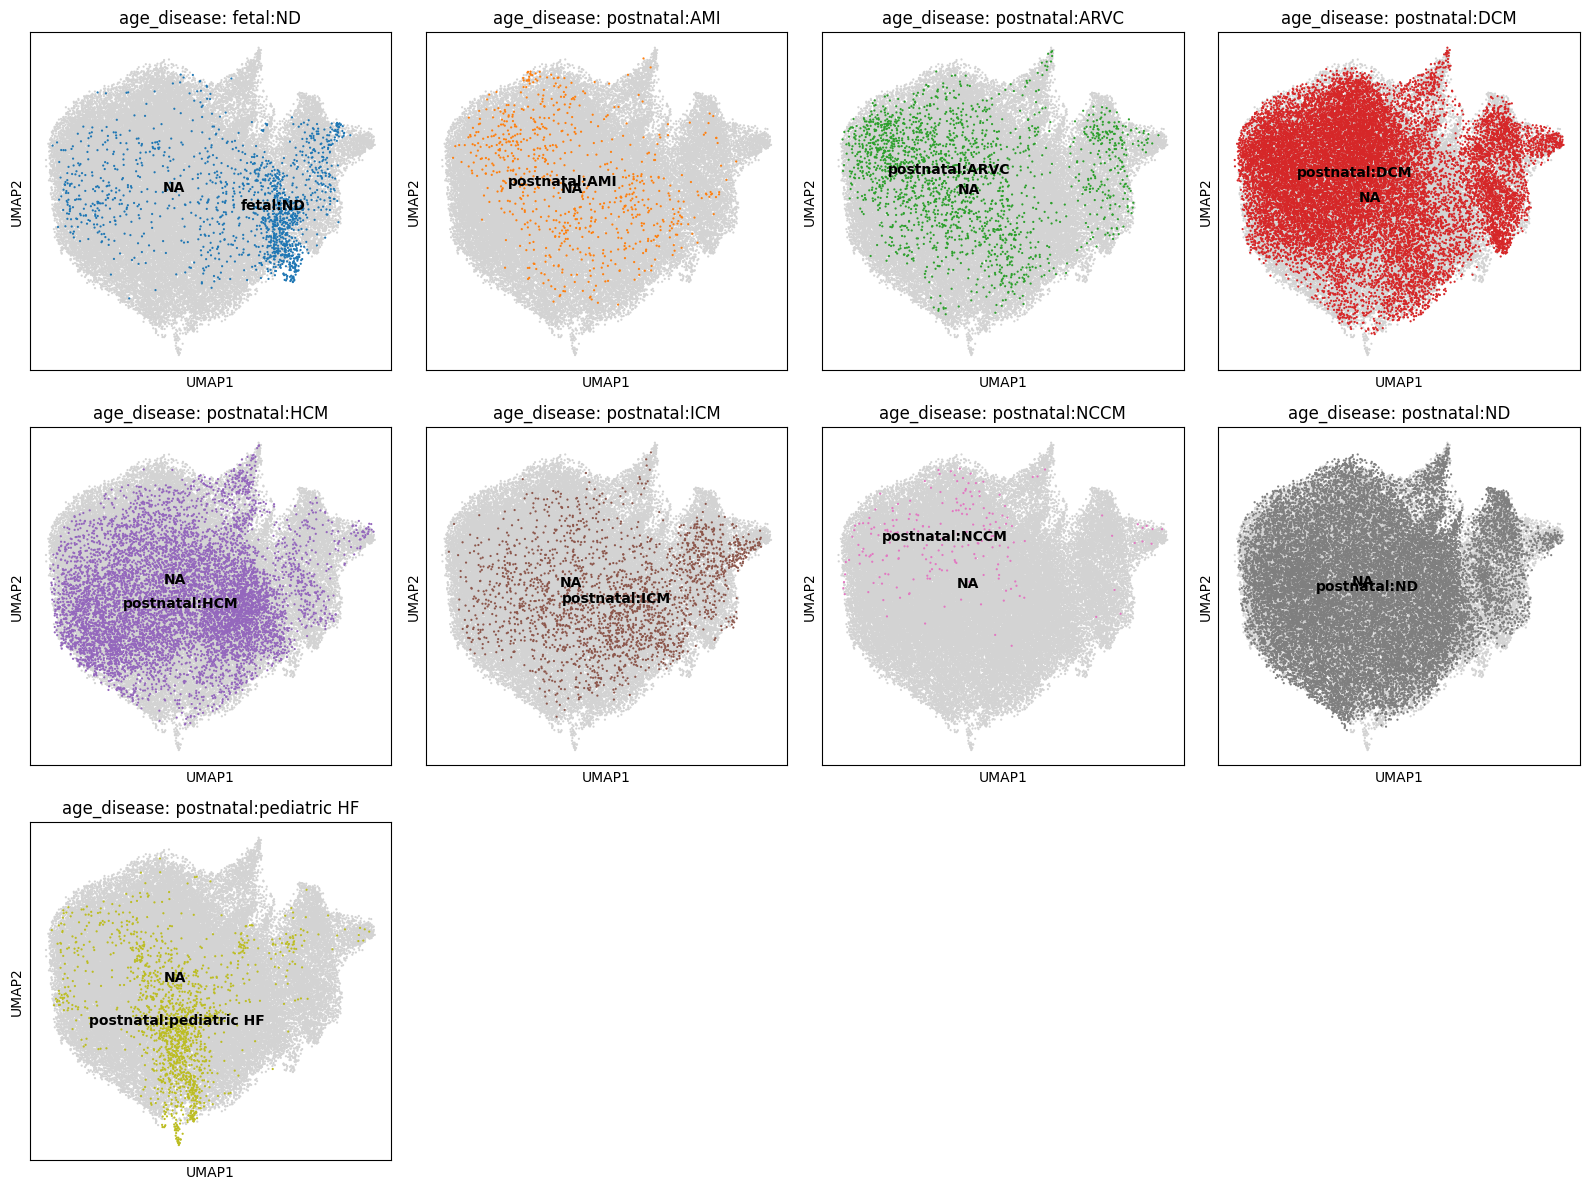

In [9]:
funcs.plot_umap_by_cluster(adata, metadata_key = "age_disease")

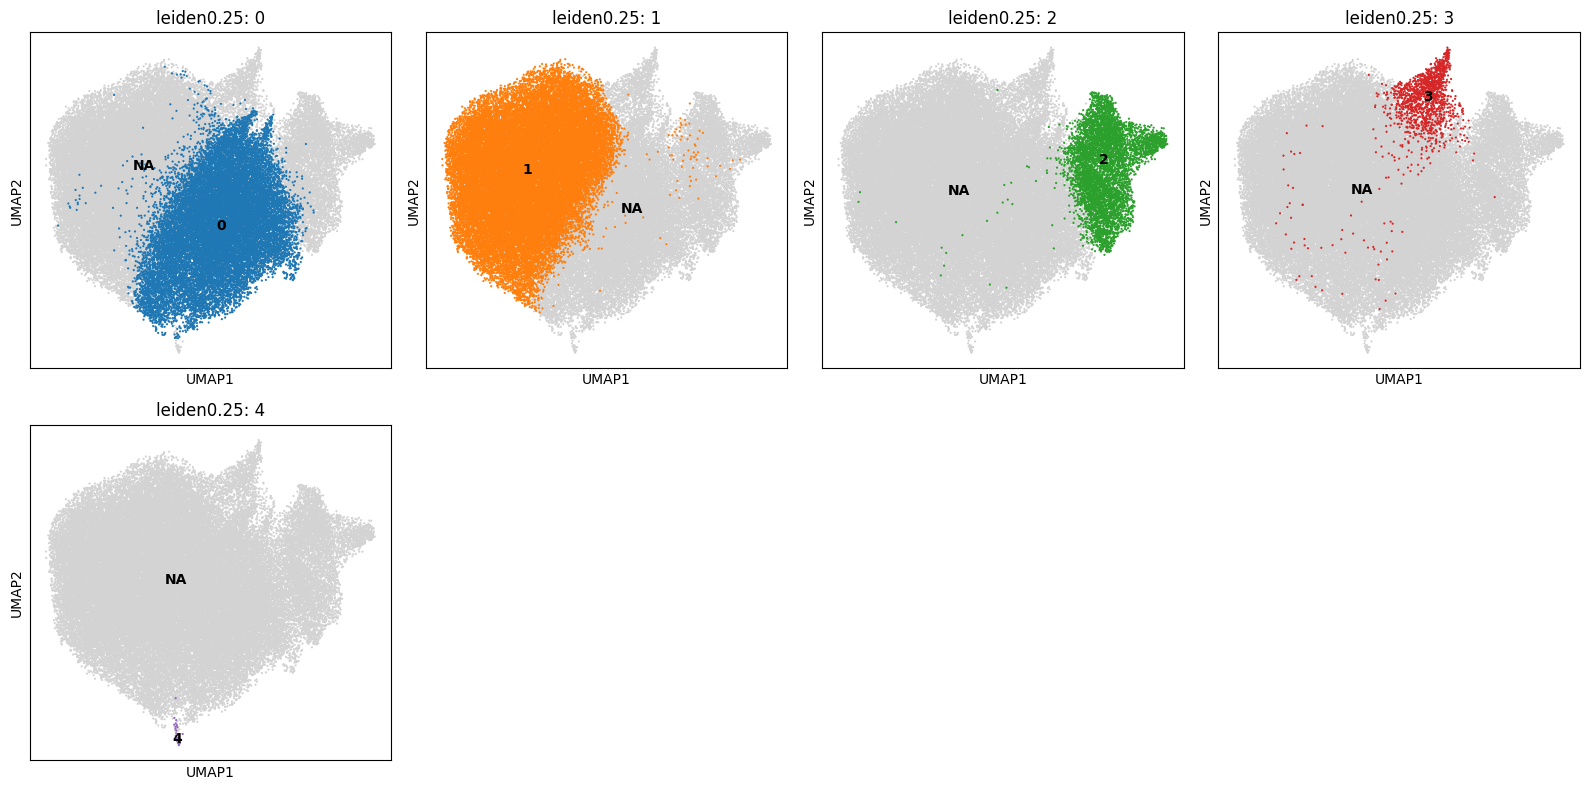

In [10]:
funcs.plot_umap_by_cluster(adata, metadata_key = leiden_key)

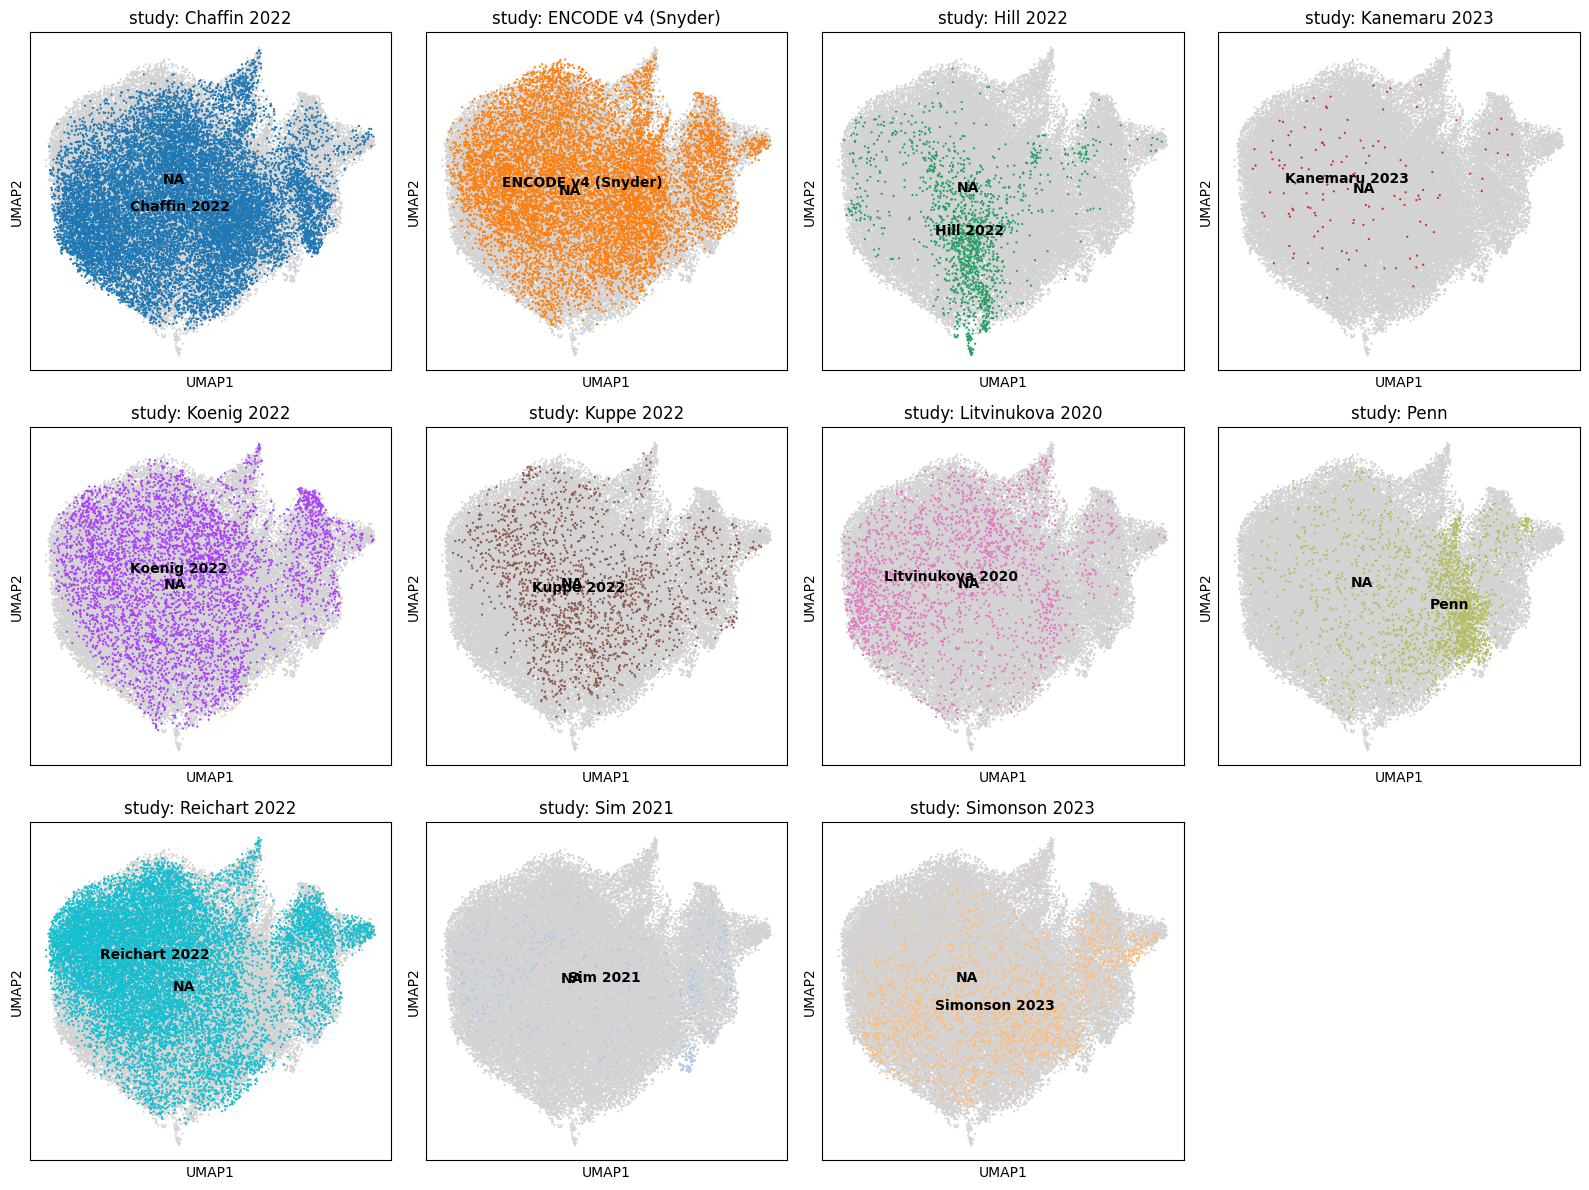

In [11]:
funcs.plot_umap_by_cluster(adata, metadata_key = "study")

### Examine enrichment along metadata categories

/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v4_subclustering_analysis/examine_covariates/perform_annotation/subcluster_funcs.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for clust, sub in metadata.groupby(cluster_label):


<module 'matplotlib.pyplot' from '/home/william/anaconda3/envs/r-kernel/lib/python3.12/site-packages/matplotlib/pyplot.py'>


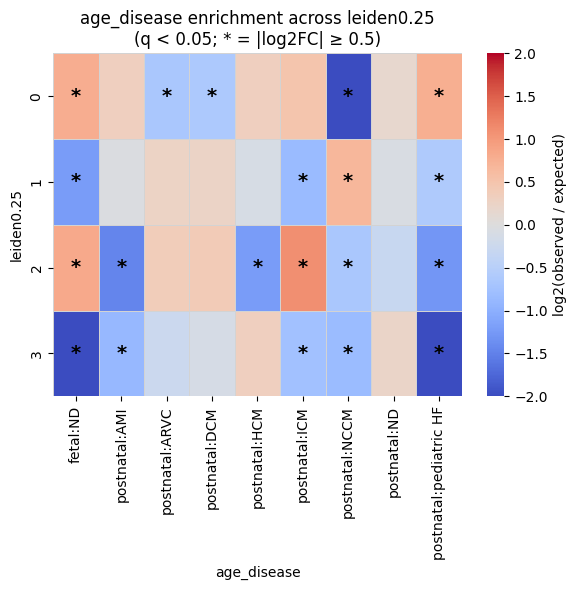

In [12]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=adata.obs,
    cluster_label=leiden_key,
    study_col="age_disease",
    min_cells=50, figsize_tuple = (6,6)
)

### Marker gene / ORA analysis

In [13]:
#Counter(adata.obs[leiden_key])

In [14]:
#sc.pl.umap(adata, color = ["HIP1"], cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True))

In [15]:
#sc.get.rank_genes_groups_df(adata, group="3").head(50)['names']

Processing Cluster 0... Success.
Processing Cluster 1... Success.
Processing Cluster 2... Success.
Processing Cluster 3... Success.
Processing Cluster 4... Success.


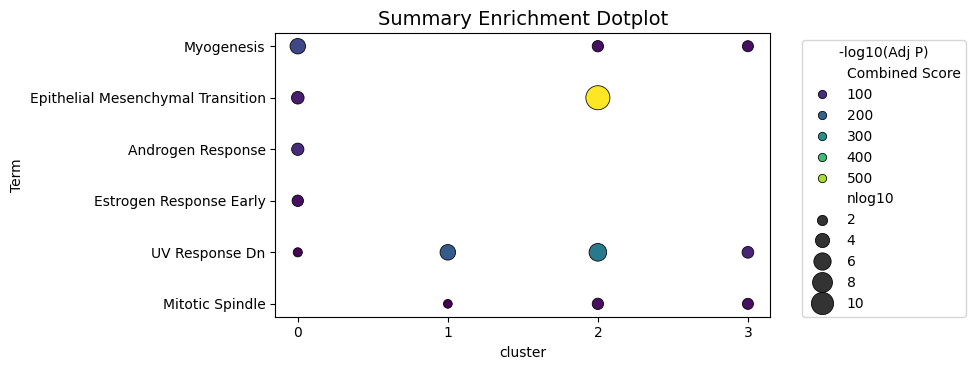

In [16]:
funcs.plot_all_cluster_enrichment(
     adata, cluster_key=leiden_key, 
     gene_sets=["MSigDB_Hallmark_2020"], outdir=None,top_n=100)

### Subcluster annotation

- Cluster 0 is the contractile vSMC (MYH11/ACTA2/SPEG)
- Cluster 1 are pericyte-like, with expression of genes such as PDGFRB/ZEB1/DLC1
- Cluster 2 are synthetic vSMC, suggesting they are fibroblast-like/fibromyocytes (DUM/COL1A1/FN1/COL1A2); MYH10 suggests non-muscle
- Cluster 3 are also contractile vSMCs: SYNPO2/SPARCL1/RBPMS/PDLIM5
- Cluster 4 is a very small cluster belonging to largely one study; join with cluster 0

In [17]:
adata.obs['subcluster'] = adata.obs['leiden0.25'].map(
    {"0": "Contractile",
     "1": "Pericyte-like",
     "2": "Synthetic",
     "3": "Contractile",
     "4": "Contractile"
    }
)

subcluster_order = [
    "Contractile",
    "Pericyte-like",
    "Synthetic", 
]

adata.obs['subcluster'] = pd.Categorical(
    adata.obs['subcluster'], categories=subcluster_order, ordered=True
)

subcluster_colors = {
    "Contractile": "cyan",
    "Pericyte-like": "orange",
    "Synthetic": "red",
}

adata.uns['subcluster_colors'] = [subcluster_colors[sc] for sc in subcluster_order]

### Produce plots

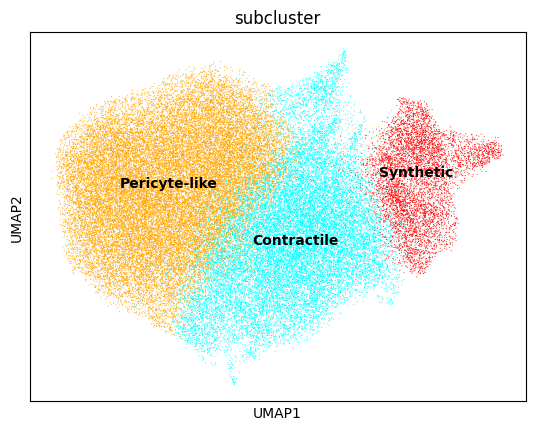

In [18]:
with plt.rc_context(): 
    sc.pl.umap(adata, color = ['subcluster'], legend_loc = "on data", palette = subcluster_colors, show=False)
    plt.savefig(plots_dir + cell_type + "_subclustered.pdf", bbox_inches="tight")

In [ ]:
with plt.rc_context(): 
    sc.pl.dotplot(adata, var_names = ["MYH11", "TAGLN", "SMTN",
                                      "PDGFRB", "ZEB1", "DLC1",
                                  "COL1A1", "FN1", "MYH10"],
                  groupby = "subcluster", standard_scale='var', show=False, dot_max=0.05)
    plt.savefig(plots_dir + cell_type + "_subclustered_dotplot.pdf", bbox_inches="tight")

### Show enrichments by disease-age status and age group

In [ ]:
adata_metadata = adata.obs

disease_filtered_metadata = adata_metadata[~adata_metadata['age_disease'].isin(["postnatal:ARVC", "postnatal:NCCM"])].copy()
for col in disease_filtered_metadata.select_dtypes('category').columns:
    disease_filtered_metadata[col] = disease_filtered_metadata[col].cat.remove_unused_categories()
    
ND_adata_metadata = adata_metadata[adata_metadata['disease_binary'] == "N"].copy()

In [ ]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=disease_filtered_metadata,
    cluster_label="subcluster",
    study_col="age_disease",
    metadata_order = ['postnatal:ND', 'fetal:ND', 'postnatal:AMI', 'postnatal:DCM', 
                      'postnatal:HCM', 'postnatal:ICM', 'postnatal:pediatric HF'],
    min_cells=50, figsize_tuple = (6,6)
)

plot.savefig(plots_dir + cell_type + "_subcluster_age_disease.pdf")

In [ ]:
test_df, enrich_df, plot = funcs.chi_square_per_subcluster(
    metadata=ND_adata_metadata,
    cluster_label="subcluster",
    metadata_order = ["fetal", "young", "middle", "old"],
    study_col="age_group",
    min_cells=50, figsize_tuple = (5,4)
)

plot.savefig(plots_dir + cell_type + "_subcluster_aging.pdf")

In [ ]:
subcluster_stats = (
    adata.obs['subcluster']
    .value_counts(normalize=False)
    .rename("count")
    .reset_index()
    .rename(columns={"index": "subcluster"})
)

subcluster_stats["proportion"] = subcluster_stats["count"] / subcluster_stats["count"].sum()

print(subcluster_stats)

### Save metadata

In [ ]:
adata.obs.to_csv(post_subclustering_dir + cell_type + "_annotation.csv")